In [14]:
import pandas as pd

In [15]:
df = pd.read_csv('bank.csv', sep=';')

In [16]:
from sklearn.model_selection import train_test_split

# 1. Reload freshly to prevent any carry-over issues
df = pd.read_csv('bank.csv', sep=';')

# 2. Convert target variable 'y' to binary
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# 3. Drop any rows where 'y' or features have missing/NaN values
df = df.dropna(subset=['y']) # Drops rows if target is NaN
df = df.dropna()            # Drops rows if any other column has NaN

# 4. Separate features and target from the cleaned dataframe
X = df.drop(columns=['y'])
y = df['y']

# 5. One-hot encode categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# 6. Ensure all encoded columns are numeric (converts True/False flags to 1/0)
X_encoded = X_encoded.astype(float)

# 7. Split into Train and Test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Fixed Preprocessing!")
print(f"Any NaNs remaining in y_train? {y_train.isna().sum()}")
print(f"Training features shape: {X_train.shape}")

Fixed Preprocessing!
Any NaNs remaining in y_train? 0
Training features shape: (3616, 42)


In [17]:
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Resample only the training data to prevent data leakage
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Original training class distribution:\n{y_train.value_counts()}")
print(f"Balanced training class distribution:\n{y_train_balanced.value_counts()}")

Original training class distribution:
y
0    3199
1     417
Name: count, dtype: int64
Balanced training class distribution:
y
0    3199
1    3199
Name: count, dtype: int64


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Initialize and train the classifier
model = RandomForestClassifier(random_state=42, n_estimators=100)
model.fit(X_train_balanced, y_train_balanced)

# Predict on test data
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Display evaluation metrics
print("--- Classification Report (Check your F1-Score here) ---")
print(classification_report(y_test, y_pred))

print("--------------------------------------------------------")
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

--- Classification Report (Check your F1-Score here) ---
              precision    recall  f1-score   support

           0       0.91      0.97      0.94       801
           1       0.53      0.29      0.37       104

    accuracy                           0.89       905
   macro avg       0.72      0.63      0.66       905
weighted avg       0.87      0.89      0.87       905

--------------------------------------------------------
AUC-ROC Score: 0.8931


In [11]:
pip install ipywidgets


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.6 MB/s eta 0:00:00


Calculating SHAP values for the full test dataset... (This may take 1-3 minutes)
Calculation complete! Handling formatting and generating plot...


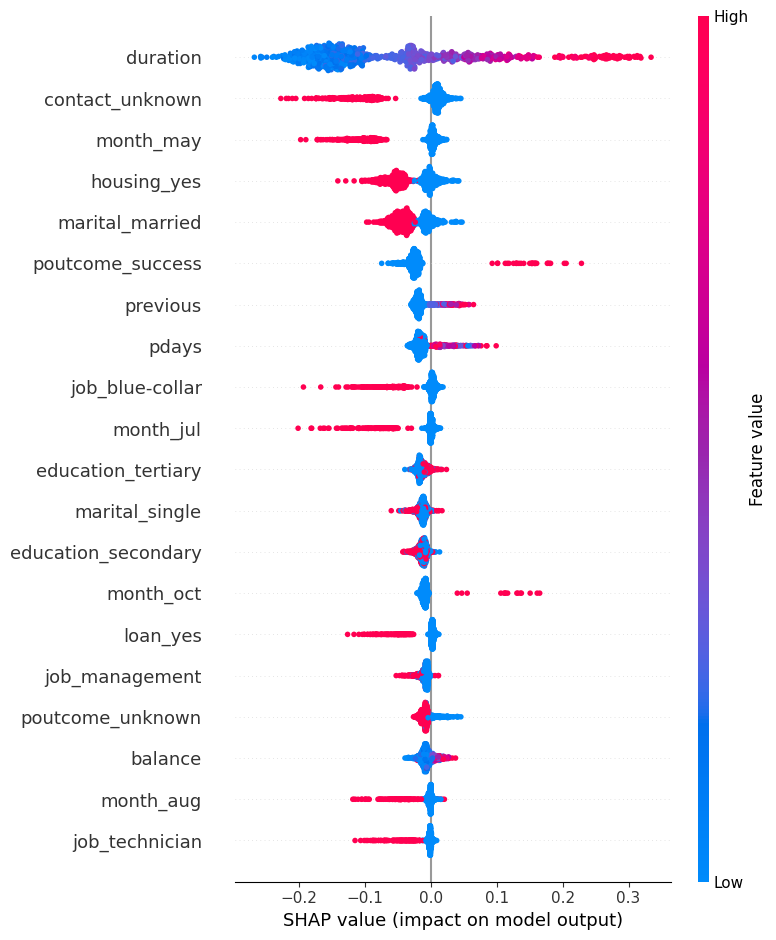

Success! 'shap_summary_full.png' has been saved to your project folder.


In [13]:
import shap
import matplotlib.pyplot as plt

print("Calculating SHAP values for the full test dataset... (This may take 1-3 minutes)")

# 1. Initialize the explainer
explainer = shap.TreeExplainer(model)

# 2. Calculate SHAP values on the complete X_test matrix
shap_values = explainer.shap_values(X_test)

print("Calculation complete! Handling formatting and generating plot...")

# 3. Dynamic shape checking to handle variations across SHAP library versions
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    shap_to_plot = shap_values[:, :, 1]
else:
    shap_to_plot = shap_values

# 4. Generate the full beeswarm summary plot
shap.summary_plot(shap_to_plot, X_test, show=False)

# 5. Save the final image to your directory for your GitHub repository documentation
plt.savefig('shap_summary_full.png', bbox_inches='tight')
plt.show()

print("Success! 'shap_summary_full.png' has been saved to your project folder.")